In [2]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from scipy.stats import pearsonr

In [3]:
# removes underground values, contains advections and mean wind profiles

with open('/home/annierosen16/master_clean.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [7]:
master['br'] = master['blc'] + master['blt']

r, p = pearsonr(master['blt'], master['br'])

print(r, p)

0.2075540680079317 0.0


In [6]:
dryapes = master[master['dryape'] == True]

wetapes = master[master['wetape'] == True]

In [5]:
corr, p_value = pearsonr(master['blc_stnd_anom'], master['blt_stnd_anom'])

print(corr)

print(p_value)

0.23498659318951207
0.0


In [7]:
corr, p_value = pearsonr(dryapes['blc_stnd_anom'], dryapes['blt_stnd_anom'])

print(corr)

print(p_value)

0.14931816438612305
0.0


In [8]:
corr, p_value = pearsonr(wetapes['blc_stnd_anom'], wetapes['blt_stnd_anom'])

print(corr)

print(p_value)

-0.1741257050824668
0.0


In [9]:
backup_dir = os.path.expanduser("~/backup_data")

file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy.npz")

data = np.load(file_path)

interpolated_qfit = data["array_4"]

print(interpolated_qfit.shape)

(2754, 201, 37, 41)


In [10]:
backup_dir = os.path.expanduser("~/backup_data")

file_path = os.path.join(backup_dir, "backup_metadata_for_buoyancy.npz")

# Step 2: Load the file
metadata = np.load(file_path, allow_pickle=True)  # allow_pickle in case times are datetime objects

# Step 3: Access variables
times = metadata["times"]

lats = metadata["lats"]

lons = metadata["lons"]

print(times.shape)

print(lats.shape)

print(lons.shape)

(2754,)
(37,)
(41,)


In [11]:
mixed_layer_q = interpolated_qfit[:, 0:50, :, :].mean(axis=1)

In [12]:
# Step 1: Wrap your numpy array with coordinates

da = xr.DataArray(
    
    interpolated_qfit,
    
    dims=["time", "level", "latitude", "longitude"],
    
    coords={"time": times, "level": np.arange(interpolated_qfit.shape[1]),
           
            "latitude": lats, "longitude": lons})

# Step 2: Average over the first 50 levels

mixed_layer_q = da.isel(level=slice(0, 50)).mean(dim="level")

# Step 3: Convert to a tidy DataFrame

mixed_layer_df = mixed_layer_q.to_dataframe(name="mixed_layer_q").reset_index()

In [13]:
mixed_layer_df['date'] = mixed_layer_df['time'].dt.date

In [14]:
# make sure master also has a date column

master["date"] = pd.to_datetime(master["date"]).dt.date   # or normalize if you want datetime

# merge on date, lat, lon

merged = master.merge(
    
    mixed_layer_df[["date", "latitude", "longitude", "mixed_layer_q"]],
    
    how="left",
    
    left_on=["date", "latitude", "longitude"],   # adjust names in master
    
    right_on=["date", "latitude", "longitude"]
)

In [15]:
grouped_merged = merged.groupby(['latitude','longitude'])['mixed_layer_q'].mean()

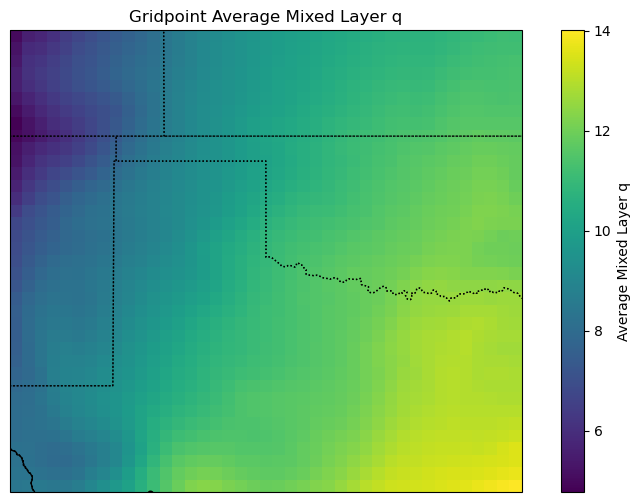

In [16]:
df_grid = grouped_merged.reset_index()

df_grid.columns = ['latitude', 'longitude', 'mixed_layer_q']

# Use pivot-like method in xarray
da = df_grid.set_index(['latitude','longitude'])['mixed_layer_q'].to_xarray()
# da now has dims ('latitude','longitude')

fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    da['longitude'],   # x-axis
    da['latitude'],    # y-axis
    da.values,         # 2D data
    cmap='viridis',
    shading='auto'
)

ax.coastlines()

ax.add_feature(cfeature.BORDERS)

ax.add_feature(cfeature.STATES, linestyle=':')

plt.colorbar(mesh, ax=ax, orientation='vertical', label='Average Mixed Layer q')

plt.title("Gridpoint Average Mixed Layer q")

plt.show()

In [17]:
merged['date'] = pd.to_datetime(merged['date'])

merged['year'] = merged['date'].dt.year

merged['month'] = merged['date'].dt.month

merged['day'] = merged['date'].dt.day

In [18]:
clim_ml_q = merged.groupby(['latitude', 'longitude', 'month', 'day'])['mixed_layer_q'].agg(['mean', 'std', 'count'])

In [19]:
clim_ml_q = clim_ml_q.reset_index()

clim_ml_q_df = clim_ml_q[['latitude', 'longitude', 'month', 'day', 'mean', 'std']]

clim_ml_q_df = clim_ml_q_df.rename(columns={'mean': 'mean_mixed_layer_q'})

clim_ml_q_df = clim_ml_q_df.rename(columns={'std': 'std_mixed_layer_q'})

In [20]:
merged_clim = merged.merge(
    
    clim_ml_q_df[["month", "day", "latitude", "longitude", "mean_mixed_layer_q", "std_mixed_layer_q"]],
    
    how="left",
    
    left_on=["month", "day", "latitude", "longitude"],   
    
    right_on=["month", "day", "latitude", "longitude"]
)

In [21]:
merged_clim['mixed_layer_q_std_anom'] = (merged_clim['mixed_layer_q'] - merged_clim['mean_mixed_layer_q']) / merged_clim['std_mixed_layer_q']

In [22]:
corr, p_value = pearsonr(merged_clim['mixed_layer_q_std_anom'], merged['blt_stnd_anom'])

print(corr)

print(p_value)

-0.12128975853683693
0.0


In [25]:
dryapes = merged_clim[merged_clim['dryape']==True]

wetapes = merged_clim[merged_clim['wetape']==True]

In [44]:
corr, p_value = pearsonr(wetapes['mixed_layer_q'], wetapes['blc'])

print(corr)

print(p_value)

-0.3331532010973595
0.0


0.23831238599827415 0.0


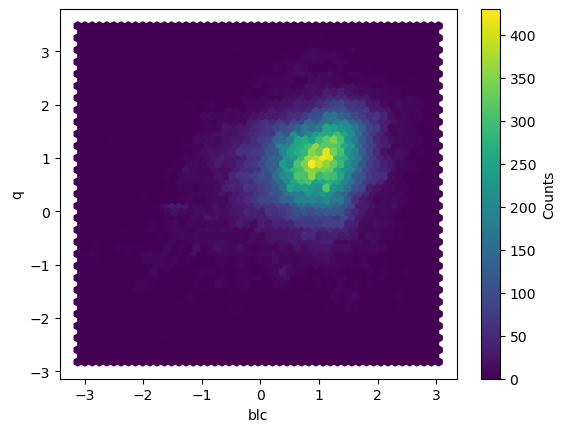

In [47]:
from scipy.stats import spearmanr

x = wetapes['blc_stnd_anom']

y = wetapes['mixed_layer_q_std_anom']

corr, p = pearsonr(x, y)

print(corr, p)

plt.hexbin(x, y, gridsize=50, cmap='viridis')

plt.xlabel("blc")

plt.ylabel("q")

plt.colorbar(label='Counts')

plt.show()

In [3]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

q_files = get_files('specific_humidity', 'specific_humidity')

all_files = u_files + v_files + q_files + w_files

# open all datasets at once

uvwq = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

In [4]:
uvwq_sgp = uvwq.sel(
    
    latitude=slice(39, 30),
    
    longitude=slice(-105, -95)
)

uvwq_sgp['time'] = uvwq_sgp['time'] - pd.Timedelta(hours=6)

uvwq_sgp = uvwq_sgp.where(
    
    (uvwq_sgp.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (uvwq_sgp.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

uvwq_sgp["w"] = uvwq_sgp["w"] * -1

In [8]:
dryapes = master[master['dryape'] == True].reset_index(drop = True)

wetapes = master[master['wetape'] == True].reset_index(drop = True)

In [11]:
_12lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 12)

_15lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 15)

### at what gridpoints is 12 LST humidity highest? is there a spatial pattern?

In [48]:
# Select level = 775

q_775 = _12lst["q"].sel(level=775)

# Convert to a pandas DataFrame

q_775_df = q_775.to_dataframe().reset_index()

q_775_df['q'] = q_775_df['q'] * 1000

q_775_df['date'] = q_775_df['time'].dt.date

dryapes['date'] = pd.to_datetime(dryapes['date'])

q_775_df['date'] = pd.to_datetime(q_775_df['date'])

In [58]:
dryapes_q_775 = dryapes.merge(q_775_df, on=['date', 'latitude', 'longitude'], how='left')

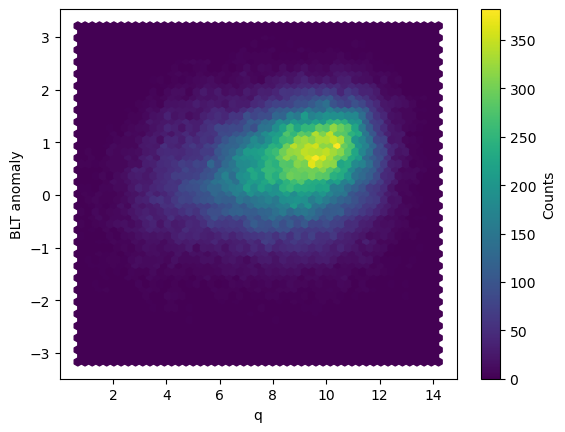

In [66]:
plt.hexbin(dryapes_q_775['q'], dryapes_q_775['blt_stnd_anom'], gridsize=50, cmap='viridis')

plt.colorbar(label='Counts')

plt.xlabel("q")

plt.ylabel("BLT anomaly")

plt.show()

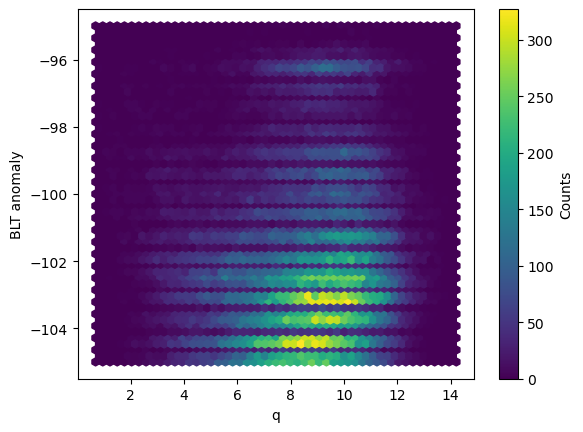

In [67]:
plt.hexbin(dryapes_q_775['q'], dryapes_q_775['longitude'], gridsize=50, cmap='viridis')

plt.colorbar(label='Counts')

plt.xlabel("q")

plt.ylabel("BLT anomaly")

plt.show()

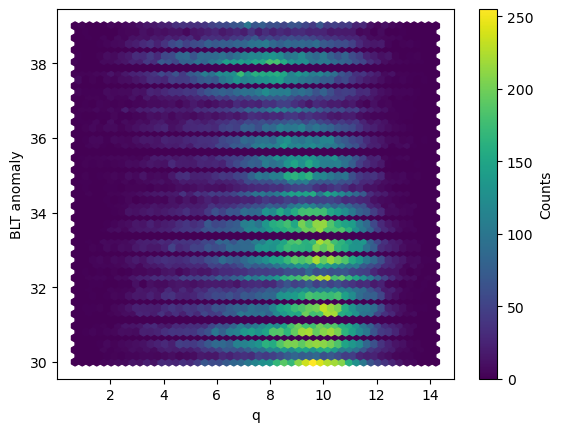

In [69]:
plt.hexbin(dryapes_q_775['q'], dryapes_q_775['latitude'], gridsize=50, cmap='viridis')

plt.colorbar(label='Counts')

plt.xlabel("q")

plt.ylabel("BLT anomaly")

plt.show()

### at what gridpoints is vertical transport high for dryapes?

In [71]:
# Select level = 800

w_800 = _12lst["w"].sel(level=800)

# Convert to a pandas DataFrame

w_800_df = w_800.to_dataframe().reset_index()

# w_775_df['q'] = q_775_df['q'] * 1000

w_800_df['date'] = w_800_df['time'].dt.date

dryapes['date'] = pd.to_datetime(dryapes['date'])

w_800_df['date'] = pd.to_datetime(w_800_df['date'])

In [72]:
dryapes_w_800 = dryapes.merge(w_800_df, on=['date', 'latitude', 'longitude'], how='left')

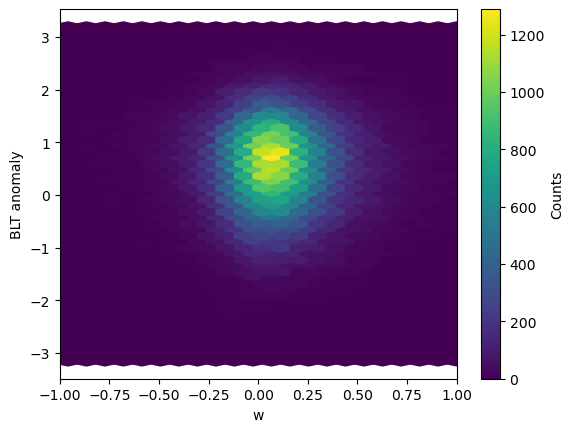

In [76]:
plt.hexbin(dryapes_w_800['w'], dryapes_w_800['blt_stnd_anom'], gridsize=50, cmap='viridis')

plt.colorbar(label='Counts')

plt.xlabel("w")

plt.xlim(-1,1)

plt.ylabel("BLT anomaly")

plt.show()

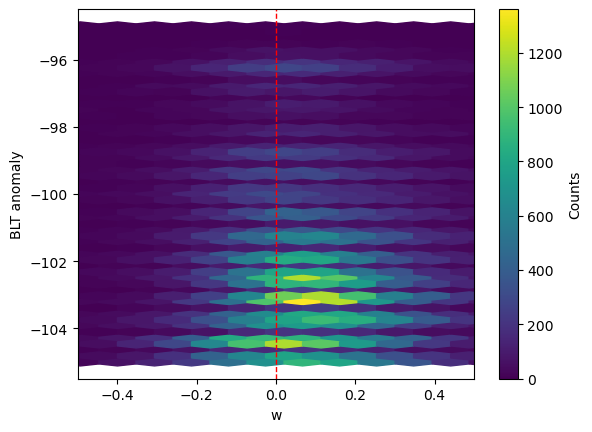

In [82]:
plt.hexbin(dryapes_w_800['w'], dryapes_w_800['longitude'], gridsize=50, cmap='viridis')

plt.colorbar(label='Counts')

plt.xlabel("w")

plt.xlim(-0.5, 0.5)

# plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.ylabel("BLT anomaly")

plt.show()

In [61]:
# pressure_levels = _12lst['level'].data * 100 

# xr_all_times = {
    
#     "12 LST": _12lst, "15 LST": _15lst
# }

# dryapes['date'] = pd.to_datetime(dryapes['date'])

# composite_profiles = {}

# for time_label, ds in xr_all_times.items():
    
#     q_profiles = ds.sel(
        
#         time=xr.DataArray(dryapes['date'].values, dims="points"),
        
#         latitude=xr.DataArray(dryapes['latitude'].values, dims="points"),
        
#         longitude=xr.DataArray(dryapes['longitude'].values, dims="points"),
        
#         method="nearest"
    
#     )['q']
    
#     sp_expanded = np.expand_dims(dryapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

#     q_profiles_masked = q_profiles.where(pressure_levels < sp_expanded)

#     q_profiles_np = q_profiles_masked.values  # Shape: (n_cases, vertical_levels)

#     # Compute the mean profile (averaged over all cases)
    
#     composite_profiles[time_label] = np.nanmean(q_profiles_np, axis=0)
    
#     print(time_label, "complete")

# q_dryapes_all_times = pd.DataFrame(composite_profiles)

In [60]:
# # Convert specific humidity to g/kg

# q_dryapes_all_times_gkg = q_dryapes_all_times * 1000

# _12lst_q = q_dryapes_all_times_gkg['12 LST']

# _15lst_q = q_dryapes_all_times_gkg['15 LST']

# pressure = _12lst['level'].data  # Assuming this is consistent for both dry and wet cases

# plt.plot(_12lst_q, pressure, label='12')

# plt.plot(_15lst_q, pressure, label='15')

# plt.gca().invert_yaxis()

# plt.grid()

# plt.legend()

# plt.show()